In [1]:
#librerias basicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns

#mapas
import folium
from folium.plugins import HeatMap
from IPython.display import display

#base de datos
import sqlite3

In [2]:
#conectar con la base de datos y cargar df

db_path = "../data/raw/mercado_inmobiliario.db"

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql("SELECT * FROM tablon_analitico", conn)

In [60]:
GRAPHICS_PATH = "../reports/graphics"

## General Gross Margin Analysis

Se construirá un **minicubo** para poder analizar el gross margin en funcion de las diversas variables categóricas.

In [3]:
# Paso 1: Seleccionar dimensiones y métricas
dimensiones = ['neighbourhood_group','neighbourhood','room_type','bedrooms_disc','accommodates_disc','beds_disc']
metricas = ['total_price_night','estimated_occupancy_l365d','yearly_revenue','adquisition_cost', 'gross_margin']

# Paso 2: Crear subset con dimensiones + métricas
minicubo = df[dimensiones + metricas]
minicubo.shape

(10874, 11)

In [4]:
# Paso 3: Pasar a transaccional las dimensiones (melt)
minicubo = minicubo.melt(id_vars=metricas, value_vars=dimensiones)
minicubo

,total_price_night,estimated_occupancy_l365d,yearly_revenue,adquisition_cost,gross_margin,variable,value
0,166.0,186,30876.0,226275.0,13.65,neighbourhood_group,Tetuán
1,223.0,30,6690.0,181252.5,3.69,neighbourhood_group,Carabanchel
2,88.0,78,6864.0,124687.5,5.50,neighbourhood_group,Puente de Vallecas
3,76.0,120,9120.0,135337.5,6.74,neighbourhood_group,Usera
4,58.0,216,12528.0,151912.5,8.25,neighbourhood_group,San Blas - Canillejas
...,...,...,...,...,...,...,...
65239,155.0,54,8370.0,135337.5,6.18,beds_disc,3_beds
65240,41.0,186,7626.0,135337.5,5.63,beds_disc,1_bed
65241,37.0,248,9176.0,135337.5,6.78,beds_disc,1_bed
65242,40.0,186,7440.0,135337.5,5.50,beds_disc,1_bed


In [5]:
# Paso 4: Agregar las métricas por variable y value. Usamos la mediana ya que es mas estable para distribuciones con outliers.
minicubo_agg = minicubo.groupby(['variable', 'value'])[metricas].median().reset_index()
minicubo_agg.head(3)

,variable,value,total_price_night,estimated_occupancy_l365d,yearly_revenue,adquisition_cost,gross_margin
0,accommodates_disc,01_One,50.0,110.0,5760.0,237525.0,2.60
1,accommodates_disc,02_Two,100.0,162.0,14025.0,283725.0,5.57
2,accommodates_disc,03_Three,126.0,156.0,19290.0,283725.0,6.95


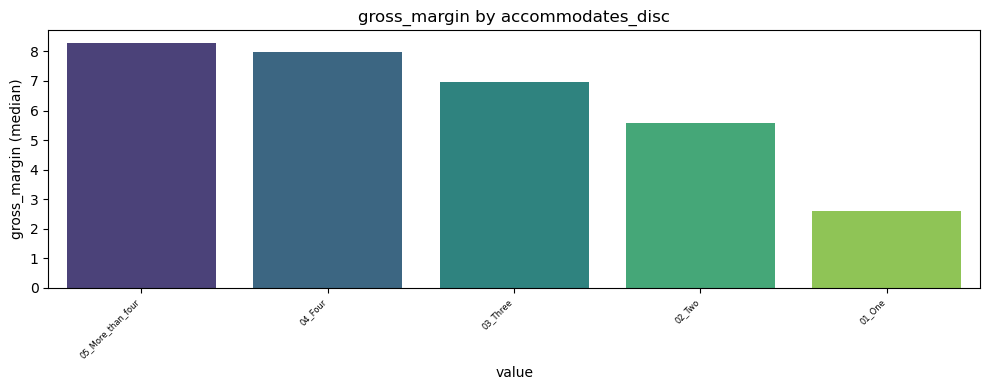

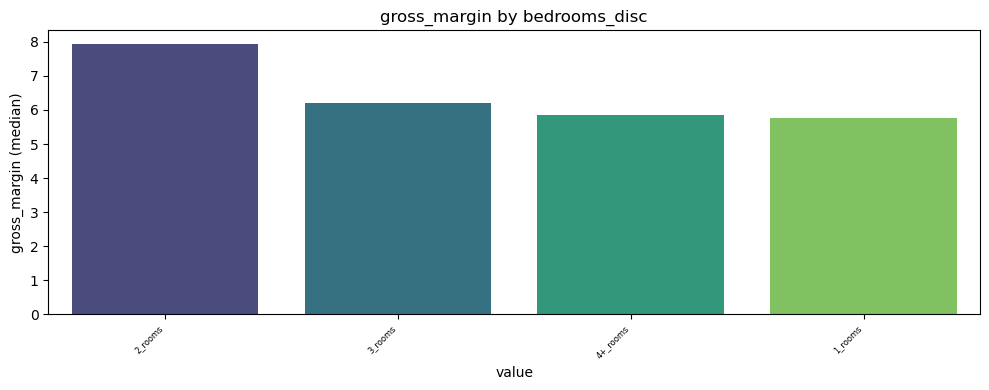

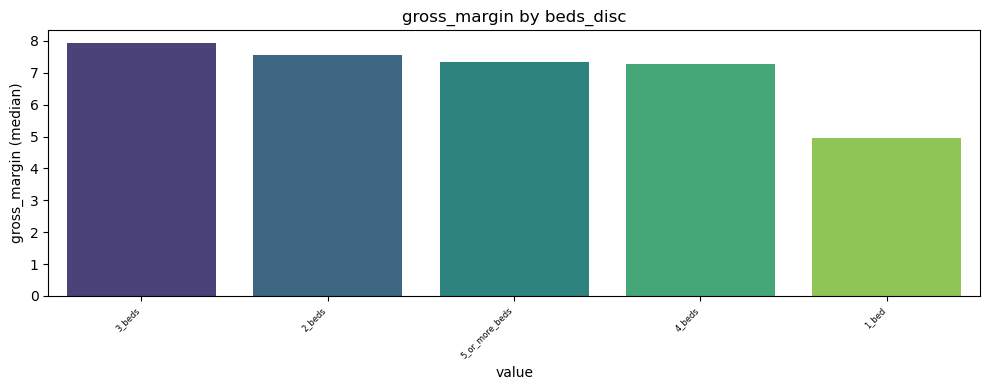

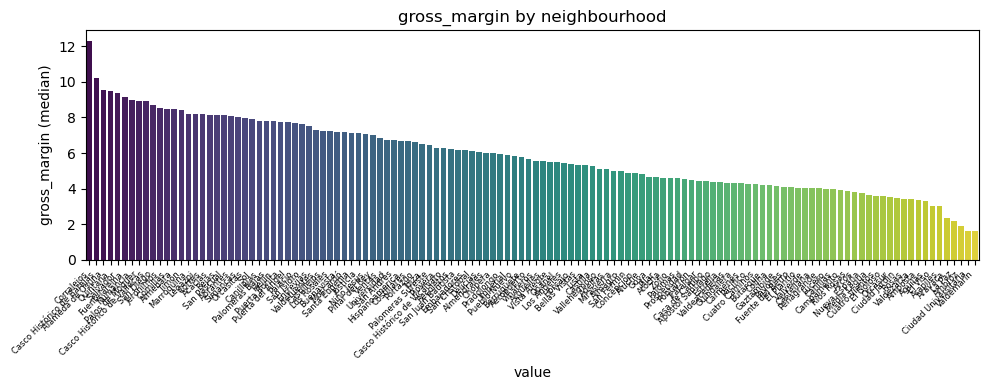

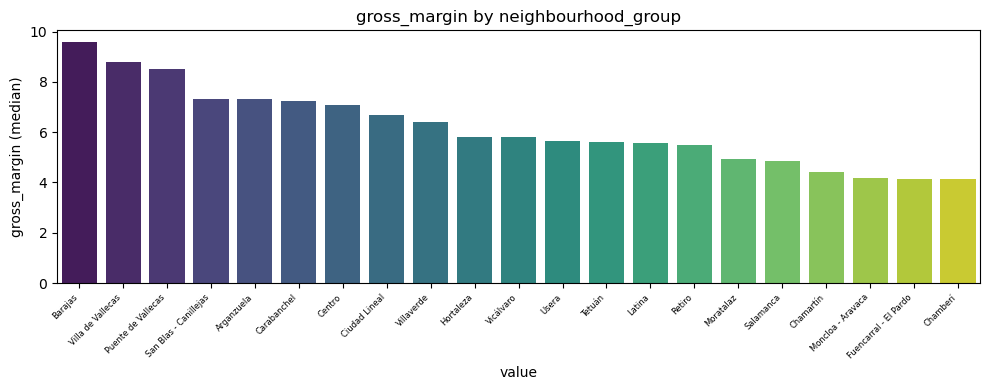

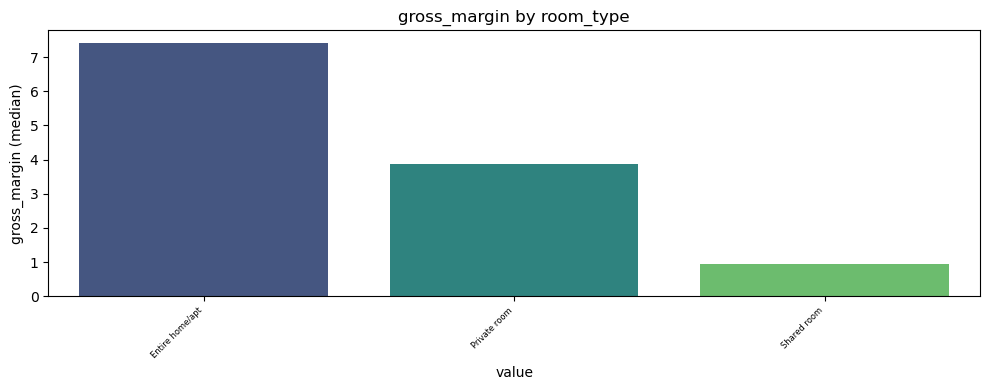

In [6]:
#Una vez preparado el cubo, vamos a analizar cada metrica en funcion de cada dimension del minicubo.

# Gross margin vs dimensions
for dimension in minicubo_agg['variable'].unique():
    datos = minicubo_agg[minicubo_agg['variable'] == dimension].sort_values('gross_margin', ascending=False)
    plt.figure(figsize=(10,4))
    sns.barplot(x='value',
                y='gross_margin',
                hue='value',
                data=datos,
                palette='viridis',
                legend=False
    )
    plt.title(f'gross_margin by {dimension}')
    plt.ylabel('gross_margin (median)')
    plt.xticks(rotation=45, ha='right', fontsize=6)
    plt.tight_layout()
    plt.show()

In [26]:
#Median gross margin vs tourist score para detectar top distritos (top gross margin y top margin+turisticos)
df_temp = (
    df.groupby('neighbourhood_group')
    .agg( 
        gross_margin = ('gross_margin', 'median'),
        tourist_score = ('tourist_score', 'median'),
        adquisition_cost = ('adquisition_cost', 'median'),
        properties = ('gross_margin', 'count'),
        median_occuppancy_365 = ('estimated_occupancy_l365d', 'median')
    )
    .sort_values('gross_margin', ascending=False)                             
)
df_temp

,gross_margin,tourist_score,adquisition_cost,properties,median_occuppancy_365
neighbourhood_group,,,,,
Barajas,9.570,0.299274,183787.5,73,255.0
Villa de Vallecas,8.780,0.474676,139387.5,39,192.0
Puente de Vallecas,8.500,7.204167,124687.5,306,132.0
San Blas - Canillejas,7.320,0.788698,151912.5,229,138.0
Arganzuela,7.300,25.518212,237525.0,585,180.0
Carabanchel,7.230,9.024509,139425.0,349,128.0
Centro,7.100,40.772006,283725.0,5046,180.0
Ciudad Lineal,6.700,4.333356,191100.0,371,156.0
Villaverde,6.400,0.754023,112575.0,83,90.0


### General Gross margin analysis findings
* Bedrooms: 2,3.

* Guests: 4 o + accommodates

* Top distritos gross margin absolutos: Barajas, Villa de Vallecas y Puente de Vallecas.

* Top distritos con **alto gross margin y alto tourist score combinado**: Centro, Arganzuela, Puente de Vallecas y Carabanchel.

* Distritos con mención especial:
    1.  **Barajas** presenta un gross margin mediano elevado y con oportunidades con un precio de adquisición relativamente bajo.
    2. **Puente de Vallecas y Carabanchel** presentan un gross margin también elevado, un tourist score aceptable y un precio de adquisición muy bajo en comparación al resto de Barrios.

* Tipo de alojamiento: Entire home/apt.

## Gross margin overview in top 6 districts
Partiendo de estos insights mas generales, empezamos a "tirar del hilo" seleccionando únicamente los 6 mejores distritos.

In [ ]:
#Filtro para descartar valores extremadamente atípicos
df_top_districts = df_top_districts.loc[df_top_districts.gross_margin.le(df.gross_margin.quantile(0.99))]

C:\Users\Jordi\AppData\Local\Temp\ipykernel_21728\1333550723.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


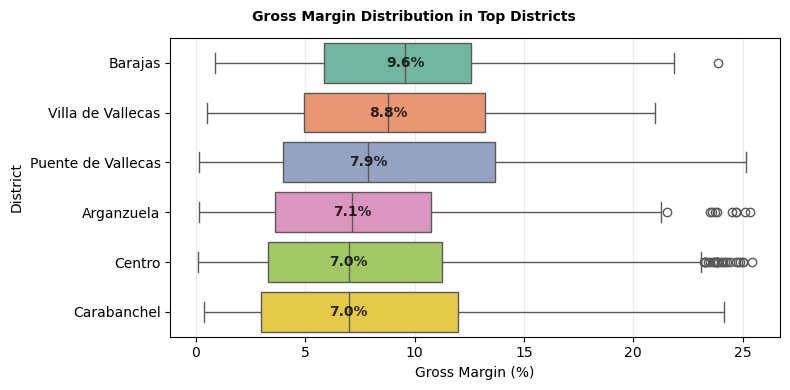

In [ ]:
# Ordenar distritos por mediana de gross margin
district_order = (
    df_top_districts
    .groupby("neighbourhood_group")["gross_margin"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(
    data=df_top_districts,
    x="gross_margin",
    y="neighbourhood_group",
    order=district_order,
    palette="Set2",
    ax=ax
)

# Añadir mediana
medians = df_top_districts.groupby("neighbourhood_group")["gross_margin"].median()

for i, district in enumerate(district_order):
    median = medians.loc[district]

    ax.text(median, i, f"{median:.1f}%", ha="center", va="center", fontweight="bold", alpha=0.8)

ax.set(
    xlabel="Gross Margin (%)",
    ylabel="District",
    title="Gross Margin Distribution by District"
)
ax.set_title("Gross Margin Distribution in Top Districts", fontsize=10, fontweight="bold", va='center',loc="center", x=0.4,  pad=15)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

plt.savefig(
    f"{GRAPHICS_PATH}/gross_margin_top_districts.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

* **Barajas** se mantiene como el Distrito con el Gross Margin mediano mas elevado y estable aunque su naturaleza no es óptima para inversión turística.
* **Puente de vallecas** tiene una buena combinacion de gross margin mediano y P75 elevado, siendo un distrito con cierto interés turistico.
* **Arganzuela, Centro y Carabanchel** muestran un comportamiento muy similar, siendo Centro el que tiene mayor validex debido a su elevado numero de inmuebles de referencia.

## Gross margin analysis in top districts

In [8]:
top_districts = ['Puente de Vallecas','Barajas','Villa de Vallecas','Centro','Arganzuela','Carabanchel']

In [9]:
df_top_districts = df[df['neighbourhood_group'].isin(top_districts)]
df_top_districts.neighbourhood_group.value_counts()

neighbourhood_group
Centro                5046
Arganzuela             585
Carabanchel            349
Puente de Vallecas     306
Barajas                 73
Villa de Vallecas       39
Name: count, dtype: int64

### Top property features with the best gross margin configuration for each district
Usaremos un minicubo para recorrer las dimensiones de inmueble y poder encontrar las mejores caracteristicas para cada distrito

In [10]:
# Paso 1: Seleccionar dimensiones y métricas
dimensiones = ['room_type','bedrooms_disc','accommodates_disc','beds_disc']
metricas = ['total_price_night','estimated_occupancy_l365d','yearly_revenue','adquisition_cost', 'gross_margin']

In [11]:
resultados = []

#Para cada distrito seleccionado creamos un minicubo y lo agregamos a la matriz resultados
for district in top_districts:

    df_district = df_top_districts[
        df_top_districts["neighbourhood_group"].eq(district)
    ]

    minicubo = df_district[dimensiones + metricas]

    minicubo = minicubo.melt(
        id_vars=metricas,
        value_vars=dimensiones,
        var_name="dimension",
        value_name="value"
    )
    #minicubo con agregacion de metricas relevantes
    agg = (
        minicubo
        .groupby(["dimension", "value"])
        .agg(
            listings=("gross_margin", "size"),
            occupancy=("estimated_occupancy_l365d", "median"),
            yearly_revenue=("yearly_revenue", "median"),
            adquisition_cost=("adquisition_cost", "median"),
            gross_margin=("gross_margin", "median")
        )
        .reset_index()
    )
    #añadimos variable de distrito y añadimos a la matriz
    agg["district"] = district
    resultados.append(agg)

In [ ]:
#concatenamos la matriz y ordenamos variables
resultados = pd.concat(resultados, ignore_index=True)
resultados = resultados.sort_values(["district", "gross_margin"], ascending=[True, False])
resultados.set_index(['district'], inplace=True)

In [15]:
resultados.loc[resultados['gross_margin'] > 8]

,dimension,value,listings,occupancy,yearly_revenue,adquisition_cost,gross_margin
district,,,,,,,
Arganzuela,beds_disc,4_beds,46,185.0,32212.0,308782.500,10.435
Arganzuela,beds_disc,5_or_more_beds,17,228.0,37740.0,522555.000,9.660
Arganzuela,beds_disc,3_beds,93,204.0,29376.0,308782.500,9.420
Arganzuela,accommodates_disc,03_Three,59,222.0,24000.0,237525.000,9.320
Arganzuela,bedrooms_disc,2_rooms,140,177.0,27984.0,308782.500,9.060
Arganzuela,accommodates_disc,05_More_than_four,99,174.0,33264.0,308782.500,9.040
Arganzuela,room_type,Entire home/apt,471,186.0,22440.0,237525.000,8.660
Barajas,bedrooms_disc,2_rooms,14,255.0,31875.0,238923.750,13.340
Barajas,beds_disc,5_or_more_beds,4,241.5,47737.5,404332.500,13.175


In [ ]:
#metricas necesarias para complementar el analisis
df_top_districts.groupby("neighbourhood_group") \
    .agg(
        median_tourist_score=("tourist_score", "median"),
        median_adquisition_cost=("adquisition_cost", "median")) \
    .sort_values(by='median_tourist_score', ascending=False)

,median_tourist_score,median_adquisition_cost
neighbourhood_group,,
Centro,40.764349,283725.0
Arganzuela,25.475499,237525.0
Carabanchel,9.001572,139425.0
Puente de Vallecas,7.204167,124687.5
Villa de Vallecas,0.474676,139387.5
Barajas,0.299274,183787.5


### Top property features with best gross margin
* Distritos top rendimiento + turisticos:
    1. Centro: Entire home/apt, 4 o 4+ accommodates, 2 rooms, 2-3-4 beds. Coste adquisición mediano de 283.725€ aprox.
    2. Arganzuela: Entire home/apt, 3 o 4+ accommodates, 2 rooms, 3-4-5+ beds. Coste adquisición mediano de 237.525€ aprox.
    3. Puente de Vallecas: Entire home/apt, 3, 4, 4+ accommodates, 2, 3 o 4+ rooms, 4, 5+ beds. Coste adquisición mediano de 124.687€ aprox. Mejor barrio en cuanto a la relación potencial turistico / coste de adquisición. 
    4. Carabanchel: Entire home/apt, 3, 4 o 4+ accommodates, 2 rooms, 2-3-4 beds. Coste adquisición mediano de 139.425€ aprox.

* Distritos top rendimiento con muy bajo atractivo turístico y alto potencial:
    1. Barajas: Entire home/apt o Private room, 3, 4, 4+ accommodates, 1, 2, 4+ rooms, 2, 3, 5+ beds. Coste adquisición mediano de 183.787€ aprox. Oportunidades mas enfocadas al viajero casual no turístico que necesita un alojamiento cerca del aeropuerto.
    2. Villa de Vallecas: Entire home/apt, 3, 4 o 4+ accommodates, 2 rooms, 2-3-4 beds.
 
* Tanto Barajas como Villa de Vallecas no deberian considerarse como opciones válidas si un requisito obligatorio es que el alojamiento tenga atractivo turístico.

### Potential gross margin with top configurations in top districts

In [3]:
#Diccionario de top configuraciones para cada distrito
top_configurations = {
    "Centro": {
        "room_type": ["Entire home/apt"],
        "accommodates_disc": ["04_Four", "05_More_than_four"],
        "bedrooms_disc": ["2_rooms"],
        "beds_disc": ["2_beds", "3_beds", "4_beds"]
    },

    "Arganzuela": {
        "room_type": ["Entire home/apt"],
        "accommodates_disc": ["03_Three", "04_Four", "05_More_than_four"],
        "bedrooms_disc": ["2_rooms"],
        "beds_disc": ["3_beds","4_beds","5_or_more_beds"]
    },

    "Puente de Vallecas": {
        "room_type": ["Entire home/apt"],
        "accommodates_disc": ["03_Three", "04_Four", "05_More_than_four"],
        "bedrooms_disc": ["2_rooms", "3_rooms", "4+_rooms"],
        "beds_disc": ["4_beds", "5_or_more_beds"]
    },

    "Carabanchel": {
        "room_type": ["Entire home/apt"],
        "accommodates_disc": ["03_Three", "04_Four","05_More_than_four"],
        "bedrooms_disc": ["2_rooms"],
        "beds_disc": ["2_beds", "3_beds","4_beds"]
    },

    "Barajas": {
        "room_type": ["Entire home/apt","Private room"],
        "accommodates_disc": ["03_Three", "04_Four","05_More_than_four"],
        "bedrooms_disc": ["1_rooms", "2_rooms","4+_rooms"],
        "beds_disc": ["2_beds", "3_beds", "5_or_more_beds"]
    },

    "Villa de Vallecas": {
        "room_type": ["Entire home/apt"],
        "accommodates_disc": ["03_Three", "04_Four", "05_More_than_four"
        ],
        "bedrooms_disc": ["2_rooms"],
        "beds_disc": ["2_beds", "3_beds", "4_beds"]
    }
}

Aplicamos las configuraciones para extraer gross margin potencial en top distritos

In [5]:
percentiles = [0.75, 0.90, 0.95, 0.99]


for district, config in top_configurations.items():

    properties = df[
        (df["neighbourhood_group"] == district) &
        (df["room_type"].isin(config["room_type"])) &
        (df["accommodates_disc"].isin(config["accommodates_disc"])) &
        (df["bedrooms_disc"].isin(config["bedrooms_disc"])) &
        (df["beds_disc"].isin(config["beds_disc"]))
    ]

    print(f"District: {district}")

    if properties.empty:
        print("No properties found for this configuration.\n")
        continue

    for percentile in percentiles:

        threshold = properties["gross_margin"].quantile(percentile)
        n_above = (properties["gross_margin"] >= threshold).sum()

        print(
            f"P{int(percentile * 100)}: "
            f"{threshold:.2f}% gross margin "
            f"| Top {int((1-percentile)*100)}%: {n_above} properties "
            f"| Total: {len(properties)}"
        )


District: Centro
P75: 13.83% gross margin | Top 25%: 251 properties | Total: 994
P90: 17.97% gross margin | Top 9%: 100 properties | Total: 994
P95: 21.24% gross margin | Top 5%: 50 properties | Total: 994
P99: 30.06% gross margin | Top 1%: 10 properties | Total: 994
District: Arganzuela
P75: 16.14% gross margin | Top 25%: 21 properties | Total: 83
P90: 20.94% gross margin | Top 9%: 9 properties | Total: 83
P95: 24.67% gross margin | Top 5%: 5 properties | Total: 83
P99: 31.05% gross margin | Top 1%: 1 properties | Total: 83
District: Puente de Vallecas
P75: 17.59% gross margin | Top 25%: 6 properties | Total: 22
P90: 22.43% gross margin | Top 9%: 3 properties | Total: 22
P95: 25.96% gross margin | Top 5%: 2 properties | Total: 22
P99: 29.72% gross margin | Top 1%: 1 properties | Total: 22
District: Carabanchel
P75: 14.35% gross margin | Top 25%: 20 properties | Total: 77
P90: 18.60% gross margin | Top 9%: 8 properties | Total: 77
P95: 21.03% gross margin | Top 5%: 4 properties | Total

### Insight: Potential gross margin with top configurations

1. **Arganzuela y Puente de Vallecas** destacan por su mayor potencial de gross margin, alcanzando un P75 del **16,14%** y **17,59%**, respectivamente. Puente de Vallecas requiere cautela por su muestra reducida (**6 propiedades**).

2. **Centro** ofrece el resultado más fiable por su amplia muestra (**221 propiedades**) en el P75 y mantiene un potencial sólido, con un P90 del **17,97%**.

3. **Carabanchel** presenta un buen equilibrio entre rentabilidad y tamaño de muestra (**77 propiedades**), mientras que **Barajas y Villa de Vallecas** tienen muestras demasiado pequeñas para extraer conclusiones robustas y, además, menor atractivo turístico.


### Gross Margin Calculator Tool
Esta funcion localizada en *../src/preprocessing.py* permite encontrar el **potencial gross margin para una configuración concreta de inmueble.** De todas formas, se ha desarrollado con un objetivo puramente académico y en la realidad deberia contener muchos mas parámetros que se deberian consultar con el departamento de negocio.

In [22]:
import sys
sys.path.append("../src")

from preprocessing import estimate_gross_margin

Con el objetivo de encontrar mas inmuebles de referencia se han ajustado dos parámetros:
1. beds se añade en formato lista pudiendo añadir una cantidad variable
2. accommodates representa el valor maximo de accommodates que podria alojar el inmueble.

In [23]:
#Ejemplo de uso
estimate_gross_margin(
    df=df,
    district="Centro",
    neighbourhood="Sol",
    bedrooms=2,
    beds=[2,3],
    accommodates=4,
    room_type="Entire home/apt"
)

District: Centro
Neighbourhood: Sol
Configuration: 2 bedrooms, [2, 3] beds, 4 maximum accommodates, Entire home/apt
Properties: 69
50 percentile: 13.11% gross margin | Properties: 35)
75 percentile: 17.21% gross margin | Properties: 18)
90 percentile: 22.23% gross margin | Properties: 7)
95 percentile: 26.64% gross margin | Properties: 4)
99 percentile: 33.52% gross margin | Properties: 1)


En el distrito Centro, barrio Sol, en inmuebles con 2 bedrooms, 2 o 3 beds, maximo 4 accommodates y Entire home/apt se han encontrado 69 inmuebles de referencia que muestran un potencial gross margin de hasta el 33.52% siendo la mediana un 13.11%.

## Occuppancy Analysis
El analisis de ocupación tendrá el objetivo de analizar las oportunidades de inversión no tanto desde el punto de vista del tipo de inmueble sino desde la potencial ocupacion del mismo. Esto puede ser interesante para encontrar opciones **que aseguren una ocupación anual estable en casos en los que la inversión deba ser mas segura y con bajo riesgo.**

In [141]:
df['estimated_occupancy_l365d'].describe(percentiles=[0.5, 0.55, 0.6, 0.65,0.75])

count    10874.000000
mean       152.748483
std         87.458075
min         12.000000
50%        156.000000
55%        174.000000
60%        198.000000
65%        222.000000
75%        255.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64

Margen bruto con ocupacion del inmueble >= mediana

In [80]:
#Margen bruto mediano con ocupacion del inmueble >= mediana
df_temp = (
    df.loc[df.estimated_occupancy_l365d.ge(df.estimated_occupancy_l365d.median())]
    .groupby('neighbourhood_group')
    .agg(
        properties = ('gross_margin', 'count'),
        gross_margin = ('gross_margin', 'median')
    )
    .sort_values('gross_margin', ascending=False)                            
)
df_temp

,properties,gross_margin
neighbourhood_group,,
Puente de Vallecas,140,14.230
Carabanchel,151,12.660
Latina,84,12.330
Villa de Vallecas,25,12.270
San Blas - Canillejas,106,12.255
Vicálvaro,14,11.995
Ciudad Lineal,186,11.845
Villaverde,26,11.665
Usera,90,10.835


### Insight: Barrios con mejores gross margin en inmuebles con ocupacion superior a la mediana
* Los barrios con mejor gross margin y ocupacion fiable son:
1. Centro (la fiabilidad de los datos para éste barrio en concreto es mayor que el resto por su alta cantidad de propiedadades de referencia).
2. Puente de Vallecas.
3. Carabanchel.

Muchos de los distritos con mejores tasas de ocupación y gross margin coinciden con los barrios con mayor gross margin.

### Analisis de Ocupación por barrios

In [ ]:
#Distritos ordenados por gross margin (orden eje Y)
districts_by_gross_margin = (
    df.groupby('neighbourhood_group')[['gross_margin', 'estimated_occupancy_l365d']]
    .median()
    .sort_values(by='gross_margin', ascending=False)
)
district_order_gross_margin = districts_by_gross_margin.index.tolist()

C:\Users\Jordi\AppData\Local\Temp\ipykernel_21728\3192992238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


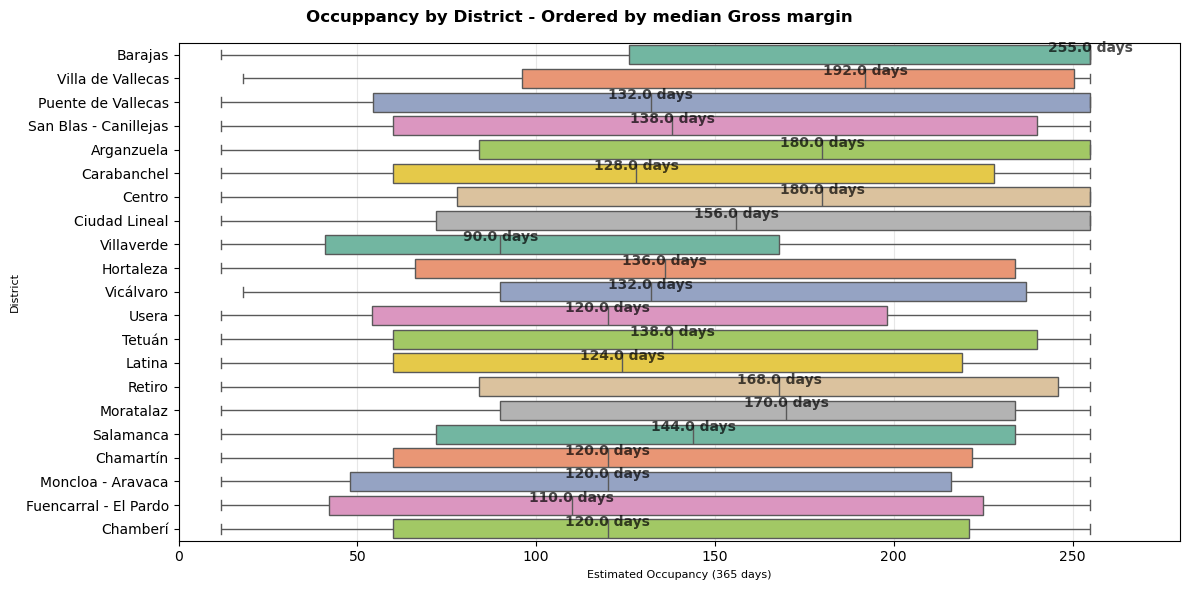

In [249]:
# Crear boxplot ordenado por la mediana
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    y='neighbourhood_group',
    x='estimated_occupancy_l365d',
    order=district_order_gross_margin,
    palette='Set2',
    ax=ax
)

# Añadir etiquetas de mediana en cada caja utilizando los valores precalculados
for i, district in enumerate(district_order_gross_margin):
    occupancy = districts_by_gross_margin.loc[district, 'estimated_occupancy_l365d']
    ax.text(occupancy, i, f'{occupancy} days', ha='center', va='bottom', fontweight='bold', alpha = 0.7)

ax.set_xlabel('Estimated Occupancy (365 days)', fontsize=8)
ax.set_ylabel('District', fontsize=8)
ax.set_title('Occuppancy by District - Ordered by median Gross margin', fontsize=12, fontweight='bold',loc="center", x=0.4,  pad=15)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(left=0)

plt.tight_layout()
plt.xlim(0, 280)
plt.savefig(
    f"{GRAPHICS_PATH}/occupancy_by_district.png",
    dpi=100,
    bbox_inches="tight"
)
plt.show()

### Insight: Occuppancy by District overview
El boxplot muestra claramente que hay un límite máximo de ocupación esperada en 255 dias, el cual proviene de los propios datos proporcionados por Airbnb.

1. **Barajas, Villa de Vallecas y Arganzuela** muestran la mejor combinación de ocupacion mediana, ocupacion maxima y gross margin.
2. **San-Blas y Puente de Vallecas** también son opciones muy ocupadas con alto gross margin.
3. **Retiro y Moratalaz** presentan ocupacion estable (P25 estable, P50 medio-alto y P75 elevado) con gross margin mediano algo inferior.

## Analisis por barrios
Se ha seleccionado **Puente de Vallecas y Carabanchel** como distritos para hacer análisis por barrios ya que son barrios que presentan una excelente combinacion entre gross margin y atractivo turistico ya que **los costes de adquisicion son muy inferiores en estos distritos y las oportunidades de inversión mucho más atractivas.**

### Neighbourhood performance

In [171]:
selected_neighbourhood_group = ['Puente de Vallecas','Carabanchel']


# Adataset por barrios agregando metricas relevantes
df_neighbourhood_summary = (
    df.loc[df["neighbourhood_group"].isin(selected_neighbourhood_group)]
    .groupby(["neighbourhood"])
    .agg(
        adquisition_cost=("adquisition_cost", "mean"),
        gross_margin=("gross_margin", "mean"),
        tourist_score=("tourist_score", "mean"),
        properties=("gross_margin", "count"),
        neighbourhood_group=("neighbourhood_group", "first")
    )
    .reset_index()
)
#Filtro de properties minimo para asegurar fiabilidad de los datos
df_neighbourhood_summary = df_neighbourhood_summary[df_neighbourhood_summary["properties"] >= 5].copy()

In [180]:
df_neighbourhood_summary[
    df_neighbourhood_summary["neighbourhood"].isin(
        ["Numancia", "San Diego", "San Isidro", "Opañel"]
    )
][["neighbourhood", "tourist_score"]].sort_values(
    "tourist_score",
    ascending=False
)

,neighbourhood,tourist_score
11,San Isidro,10.869327
5,Opañel,9.147152
4,Numancia,8.202447
10,San Diego,7.883527


In [179]:
df_neighbourhood_summary[['neighbourhood', 'neighbourhood_group','tourist_score']].sort_values('tourist_score', ascending=False)


,neighbourhood,neighbourhood_group,tourist_score
2,Comillas,Carabanchel,14.690150
11,San Isidro,Carabanchel,10.869327
5,Opañel,Carabanchel,9.147152
4,Numancia,Puente de Vallecas,8.202447
10,San Diego,Puente de Vallecas,7.883527
0,Abrantes,Carabanchel,5.249500
6,Palomeras Bajas,Puente de Vallecas,4.866657
3,Entrevías,Puente de Vallecas,4.492188
12,Vista Alegre,Carabanchel,4.351124
9,Puerta Bonita,Carabanchel,3.677301


#### Bubble quadrant chart plot

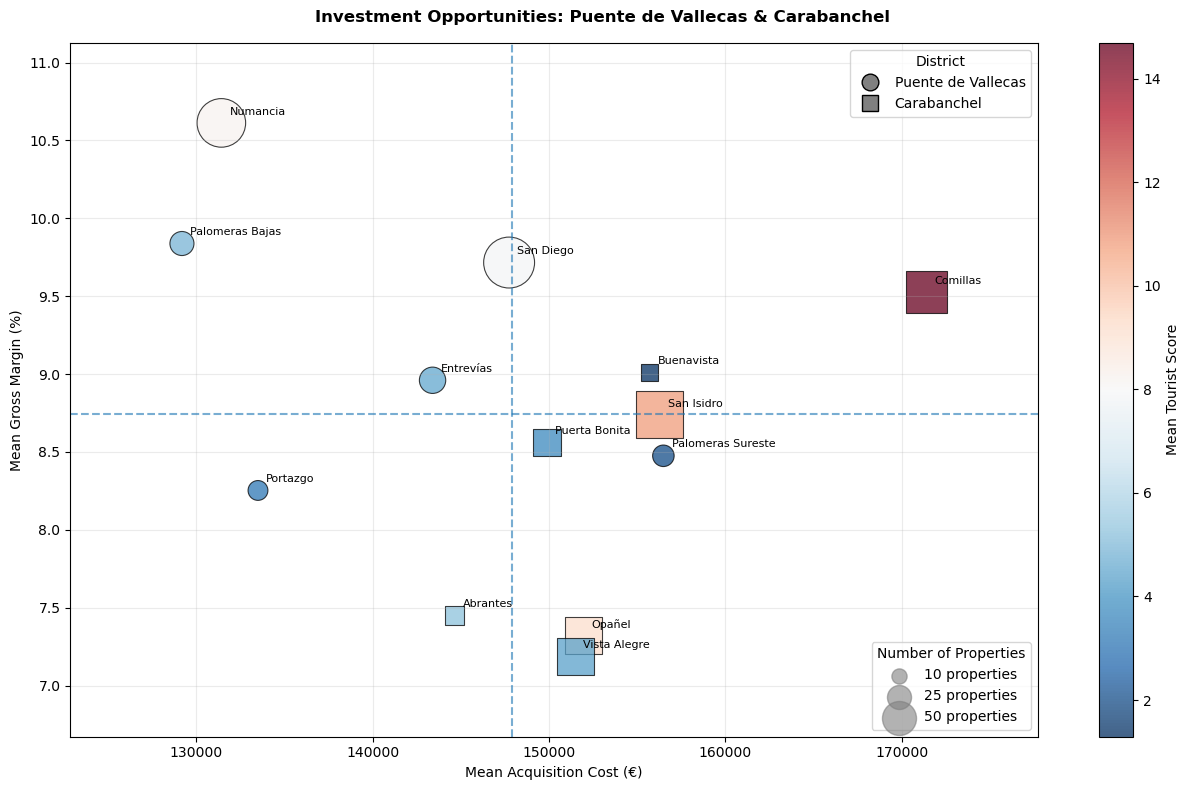

In [251]:
from matplotlib.lines import Line2D

markers = {
    "Puente de Vallecas": "o",
    "Carabanchel": "s"
}
#maximos y minimos para asegurar escala de colores comun entre todos los valores
vmin = df_neighbourhood_summary["tourist_score"].min()
vmax = df_neighbourhood_summary["tourist_score"].max()

#Valores medios para los ejes de referencia
mean_cost = df_neighbourhood_summary["adquisition_cost"].mean()
mean_margin = df_neighbourhood_summary["gross_margin"].mean()

fig, ax = plt.subplots(figsize=(13, 8))

#Puntos del scatter
for district, marker in markers.items():

    data = df_neighbourhood_summary[df_neighbourhood_summary["neighbourhood_group"] == district]

    scatter = ax.scatter(
        data["adquisition_cost"],
        data["gross_margin"],
        s=data["properties"] * 12,
        c=data["tourist_score"],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        marker=marker,
        alpha=0.75,
        edgecolors="black",
        linewidth=0.8,
    )
#Etiquetas de barrio
for _, row in df_neighbourhood_summary.iterrows():

    ax.annotate(
        row["neighbourhood"],
        (row["adquisition_cost"], row["gross_margin"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )


# Lineas de referencia de los cuadrantes
ax.axvline(mean_cost, linestyle="--", alpha=0.6)
ax.axhline(mean_margin, linestyle="--", alpha=0.6)


# Limites del grid
x_min = df_neighbourhood_summary["adquisition_cost"].min()
x_max = df_neighbourhood_summary["adquisition_cost"].max()
y_min = df_neighbourhood_summary["gross_margin"].min()
y_max = df_neighbourhood_summary["gross_margin"].max()

ax.set_xlim(x_min - (x_max - x_min) * 0.15, x_max + (x_max - x_min) * 0.15)
ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)

# Tourist score colour scale
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Mean Tourist Score")


# Leyenda 1: Indicador de distrito
district_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="gray", markeredgecolor="black", markersize=12,label="Puente de Vallecas"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="gray", markeredgecolor="black", markersize=12, label="Carabanchel")
]
district_legend = ax.legend(handles=district_handles, title="District", loc="upper right")
ax.add_artist(district_legend)


# Leyenda 2: Cantidad de propiedades
size_handles = [
    ax.scatter([], [], s=10 * 12, color="gray", alpha=0.6),
    ax.scatter([], [], s=25 * 12, color="gray", alpha=0.6),
    ax.scatter([], [], s=50 * 12, color="gray", alpha=0.6)
]
ax.legend(
    handles=size_handles,
    labels=["10 properties", "25 properties", "50 properties"],
    title="Number of Properties",
    loc="lower right",
)

#Titulos y labels
ax.set(xlabel="Mean Acquisition Cost (€)", ylabel="Mean Gross Margin (%)")
ax.set_title("Investment Opportunities: Puente de Vallecas & Carabanchel", fontsize=12, fontweight="bold", x=0.55, loc="center",  pad=15)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(
    f"{GRAPHICS_PATH}/neighbourhood_investment_opportunities.png",
    dpi=100,
    bbox_inches="tight"
)
plt.show()

In [197]:
#Comprovacion de colores del scatter segun atractivo turistico
df.loc[df.neighbourhood_group.isin(selected_neighbourhood_group)] \
.groupby(['neighbourhood_group', 'neighbourhood']).tourist_score.mean().reset_index().sort_values('tourist_score', ascending=False).head(3)

,neighbourhood_group,neighbourhood,tourist_score
2,Carabanchel,Comillas,14.690150
5,Carabanchel,San Isidro,10.869327
3,Carabanchel,Opañel,9.147152


In [196]:
# Barrios de cada Distrito seleccionado
(df.loc[df.neighbourhood_group.isin(selected_neighbourhood_group)]
    .groupby("neighbourhood_group")["neighbourhood"].unique()
    .reset_index())

,neighbourhood_group,neighbourhood
0,Carabanchel,"[Opañel, Comillas, San Isidro, Puerta Bonita, Abrantes, Buenavista, Vista Alegre]"
1,Puente de Vallecas,"[San Diego, Portazgo, Numancia, Entrevías, Palomeras Bajas, Palomeras Sureste]"


### Insight de oportunidades de Puente de Vallecas y Carabanchel
1. Top barrios gross margin + turistico: Comillas, Numancia, San Diego y San Isidro.
2. Top barrios low cost: Numancia, Palomeras Bajas, Portazgo, Entrevías, San Diego.
3. Top barrios turisticos: Comillas, San Isidro, Opañel.

* Conclusión: **Numancia, San Diego y San Isidro** se muestran como las mejores opciones de inversión si se quiere priorizar un enfoque turistico y bajo coste de adquisicón. Por otro lado si se quiere priorizar principalmente el atractivo turistico y no hay limitaciones elevadas de adquisición, se recomienda invertir en **Comillas, San Isidro y Opañel** ya que con una gestión profesional pueden alcanzar valores de gross margin mucho mas elevados que la media que muestra el gráfico.

### Oportunidades con configuración de inmueble específica
Este análisis muestra en forma de ranking, configuraciones de inmuebles ordenadas por revenue potencial. Debido a que la cantidad de inmuebels para ciertas configuraciones es realmente bajo, se ha tomado el valor mínimo de 5 inmuebles para que los valores de referencia sean minimamente estables.

In [198]:
#dataset agrupado por posibles configuraciones, ordenado por gross margin
df_neighbourhood = (
    df.loc[df.neighbourhood_group.isin(selected_neighbourhood_group)]
    .groupby(['neighbourhood','room_type','bedrooms_disc','accommodates_disc','beds_disc'])
    .agg(
        estimated_occupancy_l365d = ('estimated_occupancy_l365d', 'mean'),
        yearly_revenue = ('yearly_revenue', 'mean'),
        adquisition_cost = ('adquisition_cost', 'mean'),
        gross_margin = ('gross_margin', 'mean'),
        properties = ('gross_margin', 'count')
    )
    .reset_index()
    .sort_values(by='gross_margin', ascending=False)
)

In [199]:
df_neighbourhood.loc[df_neighbourhood.properties > 5].head(20)

,neighbourhood,room_type,bedrooms_disc,accommodates_disc,beds_disc,estimated_occupancy_l365d,yearly_revenue,adquisition_cost,gross_margin,properties
20,Comillas,Entire home/apt,1_rooms,04_Four,2_beds,190.500000,20968.500000,139425.00,15.038750,8
52,Numancia,Entire home/apt,1_rooms,03_Three,2_beds,178.285714,18274.285714,124687.50,14.655714,7
118,Puerta Bonita,Entire home/apt,1_rooms,04_Four,2_beds,200.166667,20269.500000,139425.00,14.538333,6
179,Vista Alegre,Entire home/apt,1_rooms,04_Four,2_beds,172.500000,17241.000000,139425.00,12.365000,6
131,San Diego,Entire home/apt,1_rooms,04_Four,2_beds,142.000000,14978.812500,124687.50,12.011875,16
134,San Diego,Entire home/apt,2_rooms,04_Four,2_beds,178.363636,18861.000000,162093.75,11.635455,11
161,San Isidro,Entire home/apt,2_rooms,04_Four,3_beds,189.000000,20734.500000,181252.50,11.440000,6
90,Palomeras Bajas,Entire home/apt,1_rooms,04_Four,2_beds,140.666667,14208.333333,124687.50,11.394444,9
17,Comillas,Entire home/apt,1_rooms,02_Two,1_bed,178.100000,15712.800000,139425.00,11.270000,10
54,Numancia,Entire home/apt,1_rooms,04_Four,2_beds,132.352941,14029.058824,124687.50,11.251176,17


### Insights de ranking de configuraciones con alto rendimiento
Los barrios de las configuraciones con mayor rendimiento suelen conicidir con los barrios con mayor potencial observados en el bubble chart plot. Esto indica que este analisis, aunque es menos fiable que el anterior debido a la baja poblacion por configuracion, sigue aportando valor.

* Top 5 configuraciones por gross margin:
1. **Comillas:** Entire home/apt, 1 room, 4 accomodates, 2 beds | gross margin: 15% | Properties: 8
2. **Numancia:** Entire home/apt, 1 room, 3 accomodates, 2 beds | gross margin: 14,65% | Properties: 7
3. **Puerta Bonita:** Entire home/apt, 1 room, 4 accomodates, 2 beds | gross margin: 14,53% | Properties: 6
4. **Vista Alegre:** Entire home/apt, 1 room, 4 accomodates, 2 beds | gross margin: 12,36% | Properties: 6
5. **San Diego:** Entire home/apt, 2 room, 4 accomodates, 2 beds | gross margin: 11,63% | Properties: 11

**Conclusión**: las configuraciones mas repetidas en el top son Entire home/apt, 1 room, 4 accomodates, 2 beds, y el room type prediminante en el top 20 es Entire home/apt (18/20 opciones).

## Heatmaps (gross margin)

Mapa de calor global de Madrid

In [202]:
#Mapa de rentabilidad (margen_bruto)
df_map = df.dropna(subset=['latitude','longitude','gross_margin'])
madrid_coords = [40.4168, -3.7038]
m = folium.Map(location=madrid_coords, zoom_start=11)

heat_data = df_map[["latitude", "longitude", "tourist_score"]].values.tolist()
HeatMap(
        heat_data,
        radius=8,
        blur=15,
        max_zoom=1,
        min_opacity=0.4,
        max_opacity=0.8,
        gradient={0.2: "blue", 0.5: "lime", 0.8: "red"},
    ).add_to(m)

m.save('../reports/maps/profitability_map_madrid.html')

In [206]:
df.estimated_occupancy_l365d.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

count    10874.000000
mean       152.748483
std         87.458075
min         12.000000
25%         66.000000
50%        156.000000
75%        255.000000
90%        255.000000
95%        255.000000
99%        255.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64

In [207]:
#Mapa de rentabilidad (alta rentabilidad y ocupacion)
df_oportunidades = df_map[
    (df_map['gross_margin'] >= df['gross_margin'].quantile(0.95)) &
    (df_map['estimated_occupancy_l365d'] >= df['estimated_occupancy_l365d'].median())
].copy()

madrid_coords = [40.4168, -3.7038]
m2 = folium.Map(location=madrid_coords, zoom_start=11)

for _, row in df_oportunidades.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6
    ).add_to(m2)

m.save('../reports/maps/profitability_and_occupancy_map_madrid.html')


In [ ]:
# Mapa calor de rentabilidad para Puente de Vallecas y Carabanchel
df_map_barajas = df[df['neighbourhood_group'].isin(selected_neighbourhood_group)].dropna(subset=['latitude','longitude','gross_margin'])

madrid_coords = [40.4168, -3.7038]
m3 = folium.Map(location=madrid_coords, zoom_start=11)

heat_data = df_map_barajas[["latitude", "longitude", "gross_margin"]].values.tolist()
HeatMap(
        heat_data,
        radius=8,
        blur=15,
        max_zoom=1,
        min_opacity=0.4,
        max_opacity=0.8,
        gradient={0.2: "blue", 0.5: "lime", 0.8: "red"},
    ).add_to(m3)

m3.save('../reports/maps/profitability_map_puentevallecas_carabanchel.html')
